# Brain Tumor Classification with Domain Adaptation and Test-Time Adaptation

This notebook implements a baseline Convolutional Neural Network (CNN) and an augmented CNN model for multi-class brain tumor classification using MRI images. The project uses a Kaggle dataset containing four categories: **glioma**, **meningioma**, **pituitary**, and **no tumor**.  

The notebook covers the major stages of the workflow, including dataset loading, preprocessing (resizing and normalization), data augmentation for improved generalization, model construction, training, and performance evaluation. The results from both the baseline and augmentation-enhanced models are compared to establish a foundation for future work involving domain shift simulation, domain adaptation (DA), and test-time adaptation (TTA).



In [3]:
#mount the google drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


Preprocessing

In [4]:
# set the parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2

In [23]:
import tensorflow as tf

# Load images from the dataset directory and create the training split
train_dir = "/content/drive/MyDrive/ProjectData/BrainTumor/Training"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)



print(train_ds.class_names)


Found 5712 files belonging to 4 classes.
Using 4570 files for training.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
# Load images from the dataset directory and create the validation split
valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
print(valid_ds.class_names)

Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
# Load images from the dataset directory and create the test dataset
test_dir  = "/content/drive/MyDrive/ProjectData/BrainTumor/Testing"
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print(test_ds.class_names)

Found 1311 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
# Number of classes based on directory labels
NUM_CLASSES = len(train_ds.class_names)

In [25]:
class_names = train_ds.class_names
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
# -------------------------
# Normalize datasets
# -------------------------
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
valid_ds = valid_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [10]:
from tensorflow.keras import layers, models



# ------------------------------
# Build a simple 2D CNN model
# ------------------------------
model = models.Sequential([

    layers.Input(shape=IMG_SIZE + (3,)),  # 3 channels for RGB

    # Convolution + MaxPooling blocks
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Fully connected classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # helps reduce overfitting
    layers.Dense(NUM_CLASSES, activation='softmax') # output layer
])

# Compile the model with optimizer, loss, and evaluation metric
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ------------------------------
# Train the model (with validation during training)
# ------------------------------
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=15
)

Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 629s 4s/step - accuracy: 0.5696 - loss: 1.0259 - val_accuracy: 0.8406 - val_loss: 0.4326
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 535s 4s/step - accuracy: 0.8231 - loss: 0.4605 - val_accuracy: 0.8748 - val_loss: 0.3408
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 516s 4s/step - accuracy: 0.8766 - loss: 0.3137 - val_accuracy: 0.9072 - val_loss: 0.2966
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 518s 4s/step - accuracy: 0.9173 - loss: 0.2227 - val_accuracy: 0.9124 - val_loss: 0.2486
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 567s 4s/step - accuracy: 0.9401 - loss: 0.1667 - val_accuracy: 0.9256 - val_loss: 0.2236
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 514s 4s/step - accuracy: 0.9593 - loss: 0.1125 - val_accuracy: 0.9221 - val_loss: 0.2356
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 518s 4s/step - accuracy: 0.9669 - loss: 0.0889 - val_accuracy: 0.9448 - val_loss: 0.2048
Epoch 8/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 510s 4s/step - accuracy: 0.9787 - loss: 0.0597 - val_accu

The model shows strong learning, with accuracy rising from 56% to 99% and validation accuracy stabilizing around 95%. Validation loss increases later, indicating mild overfitting.

To improve generalization and observe its impact on model performance, I applied a data-augmentation pipeline. The following code introduces random flips, rotations, zoom, and contrast adjustments before training the model.

In [12]:
# Define augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Apply augmentation ONLY to training dataset
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)


In [13]:
# ------------------------------
# 2D CNN Model with augmentation
# ------------------------------
# Build a CNN model that includes data augmentation as the first layer
# This helps the model generalize better by applying random flips, rotations,
# zooms, and contrast adjustments during training

model_aug = models.Sequential([

    # Apply data augmentation directly to input images
    data_augmentation,

    # Convolution + MaxPooling blocks
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

     # Fully connected classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])


# Compile the augmented model with same optimizer, loss, and metrics
model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture including the augmentation layer
model_aug.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

To prevent overfitting and save training time, I applied EarlyStopping to monitor validation loss, stopping training if it does not improve for 5 consecutive epochs and restoring the best model weights.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping
# ------------------------------
# Early stopping callback
# ------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

The augmented CNN model is trained for up to 30 epochs with validation monitoring, using EarlyStopping to halt training if the validation loss does not improve for 5 consecutive epochs, ensuring the best weights are restored.

In [15]:
# Train the augmented CNN model with validation monitoring
history_aug = model_aug.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=[early_stop]
)


Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 615s 4s/step - accuracy: 0.4835 - loss: 1.1587 - val_accuracy: 0.6042 - val_loss: 1.1360
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 609s 4s/step - accuracy: 0.7223 - loss: 0.7051 - val_accuracy: 0.7163 - val_loss: 0.8183
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 603s 4s/step - accuracy: 0.7667 - loss: 0.5929 - val_accuracy: 0.8100 - val_loss: 0.5309
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 605s 4s/step - accuracy: 0.7890 - loss: 0.5462 - val_accuracy: 0.8135 - val_loss: 0.4869
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 608s 4s/step - accuracy: 0.8248 - loss: 0.4550 - val_accuracy: 0.7285 - val_loss: 0.7704
Epoch 6/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 604s 4s/step - accuracy: 0.8233 - loss: 0.4478 - val_accuracy: 0.8529 - val_loss: 0.4104
Epoch 7/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 614s 4s/step - accuracy: 0.8302 - loss: 0.4333 - val_accuracy: 0.8503 - val_loss: 0.4060
Epoch 8/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.8587 - loss: 0.3676 - val_accu

The baseline (non-augmented) model achieved much higher accuracy (up to ~99% train, ~95% validation) but clearly overfitted.
The augmented model improved generalization stability, achieving ~91% train accuracy and ~89% val accuracy with fewer spikes in validation loss.


Overall, augmentation reduced overfitting but also lowered maximum accuracy due to increased learning difficulty.

In [16]:
import matplotlib.pyplot as plt

def plot_training_comparison(history_baseline, history_aug):
    # Extract baseline history
    acc_base = history_baseline.history['accuracy']
    val_acc_base = history_baseline.history['val_accuracy']
    loss_base = history_baseline.history['loss']
    val_loss_base = history_baseline.history['val_loss']

    # Extract augmented history
    acc_aug = history_aug.history['accuracy']
    val_acc_aug = history_aug.history['val_accuracy']
    loss_aug = history_aug.history['loss']
    val_loss_aug = history_aug.history['val_loss']

    # Separate epoch ranges (because early stopping changes length)
    epochs_base = range(1, len(acc_base) + 1)
    epochs_aug = range(1, len(acc_aug) + 1)

    # ---------------------- Accuracy Curve ----------------------
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_base, acc_base, label='Baseline Train Accuracy')
    plt.plot(epochs_base, val_acc_base, label='Baseline Val Accuracy')
    plt.plot(epochs_aug, acc_aug, label='Augmented Train Accuracy')
    plt.plot(epochs_aug, val_acc_aug, label='Augmented Val Accuracy')
    plt.title('Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # ---------------------- Loss Curve ----------------------
    plt.subplot(1, 2, 2)
    plt.plot(epochs_base, loss_base, label='Baseline Train Loss')
    plt.plot(epochs_base, val_loss_base, label='Baseline Val Loss')
    plt.plot(epochs_aug, loss_aug, label='Augmented Train Loss')
    plt.plot(epochs_aug, val_loss_aug, label='Augmented Val Loss')
    plt.title('Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


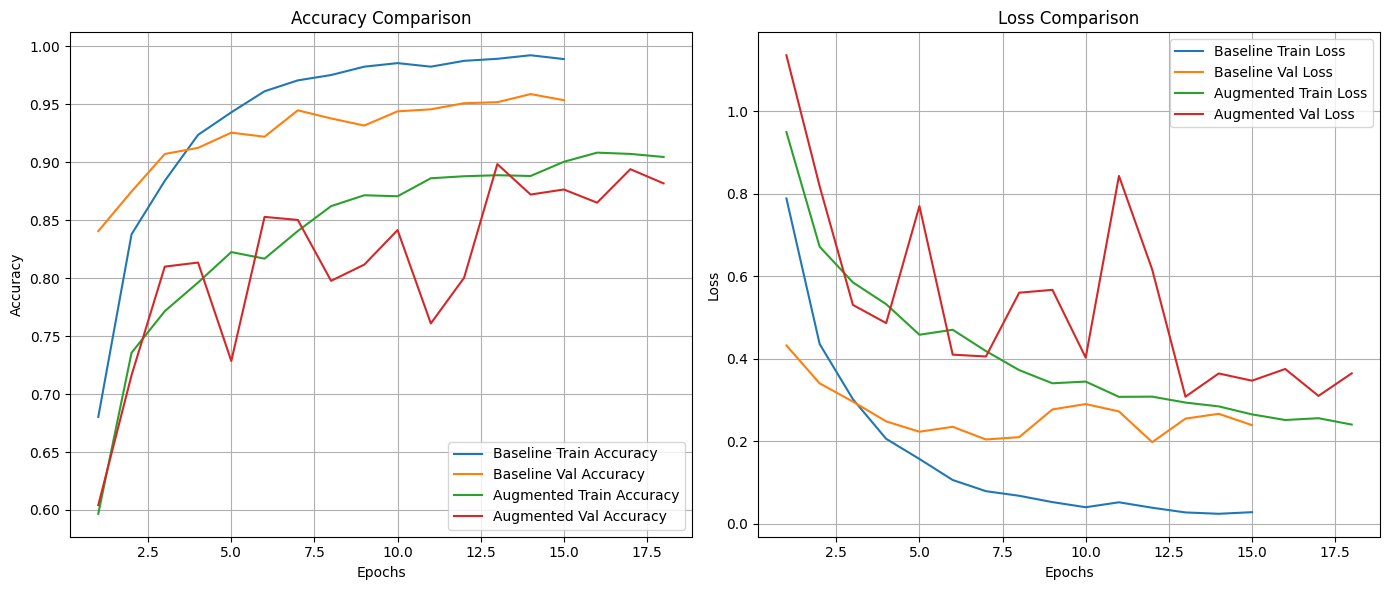

In [17]:
# Plot and compare the training/validation accuracy and loss curves
# for the baseline model (history) and the augmented model (history_aug)
plot_training_comparison(history, history_aug)


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Generate and display the confusion matrices for both models
def plot_confusion_matrix(model, test_ds, class_names):
    # Get true labels
    true_labels = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

    # Get predictions
    predictions = model.predict(test_ds)
    predicted_labels = np.argmax(predictions, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    plt.figure(figsize=(8, 6))
    disp.plot(cmap='Blues', values_format='d')
    plt.title("Confusion Matrix")
    plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step


<Figure size 800x600 with 0 Axes>

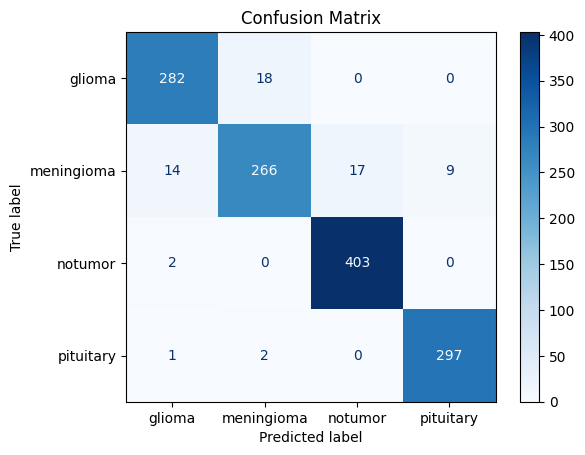

41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step


<Figure size 800x600 with 0 Axes>

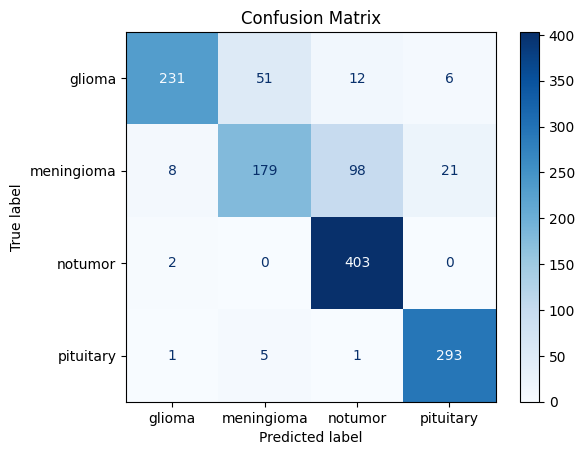

In [26]:
# Generate and display the confusion matrices for both models
# to compare their classification performance on the test dataset

# Baseline model
plot_confusion_matrix(model, test_ds, class_names)

# Augmented model
plot_confusion_matrix(model_aug, test_ds, class_names)


In [20]:
# Print the final train/validation accuracy for both baseline and augmented models
def print_model_scores(history_baseline, history_aug):
    print("==== Baseline Model ====")
    print("Final Train Acc:", history.history['accuracy'][-1])
    print("Final Val Acc:  ", history.history['val_accuracy'][-1])

    print("\n==== Augmented Model ====")
    print("Final Train Acc:", history_aug.history['accuracy'][-1])
    print("Final Val Acc:  ", history_aug.history['val_accuracy'][-1])


In [21]:
# Print the final training and validation accuracy/loss for both models
# to summarize their overall performance after training
print_model_scores(history, history_aug)

==== Baseline Model ====
Final Train Acc: 0.9890590906143188
Final Val Acc:   0.9535902142524719

==== Augmented Model ====
Final Train Acc: 0.9045951962471008
Final Val Acc:   0.8817863464355469
